In [4]:
# !pip install warnings

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# import warning
# warnings.filterwarnings('ignore')

In [21]:
import os

print(os.getcwd())

os.chdir('C:\\Users\\user\\JupyterNotebook\\iris')
print(os.getcwd())

C:\Users\user\JupyterNotebook\iris
C:\Users\user\JupyterNotebook\iris


In [24]:
iris = pd.read_csv('iris.data', header = None)
iris.shape

(150, 5)

In [27]:
iris.columns = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width', 'class']

In [28]:
df = iris.copy()
df.head()

,sepal_length,sepal_width,petal_length,petal_width,class
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


In [29]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   class         150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


In [30]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
sepal_length,150.0,5.843333,0.828066,4.3,5.1,5.80,6.4,7.9
sepal_width,150.0,3.054000,0.433594,2.0,2.8,3.00,3.3,4.4
petal_length,150.0,3.758667,1.764420,1.0,1.6,4.35,5.1,6.9
petal_width,150.0,1.198667,0.763161,0.1,0.3,1.30,1.8,2.5


In [31]:
df.isna().sum()

sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
class           0
dtype: int64

In [33]:
df['class'].value_counts()

class
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64

In [36]:
X = df.drop('class', axis=1)
X.head()

,sepal_length,sepal_width,petal_length,petal_width
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [37]:
y = df['class']
y.head()

0    Iris-setosa
1    Iris-setosa
2    Iris-setosa
3    Iris-setosa
4    Iris-setosa
Name: class, dtype: object

In [38]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [39]:
y_train.value_counts()

class
Iris-versicolor    41
Iris-setosa        40
Iris-virginica     39
Name: count, dtype: int64

In [40]:
col = X_train.columns

In [41]:
X_train = X_train.values

In [42]:
y_train = y_train.values

In [49]:
from sklearn.tree import DecisionTreeClassifier

clf = DecisionTreeClassifier(random_state=42, max_depth=2)
clf = clf.fit(X_train, y_train)

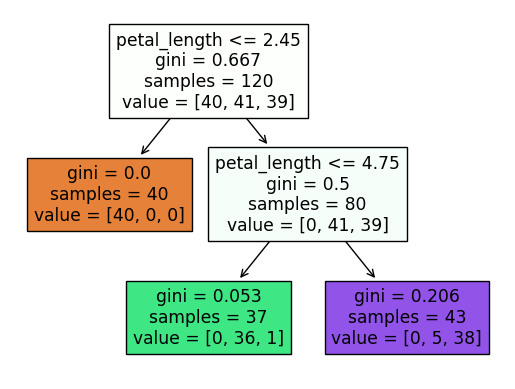

In [50]:
from sklearn.tree import plot_tree

plot_tree(clf, feature_names=col, filled=True)
plt.show()

In [51]:
y_pred = clf.predict(X_test)
y_pred

C:\Users\user\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\base.py:432: UserWarning: X has feature names, but DecisionTreeClassifier was fitted without feature names
  warnings.warn(


array(['Iris-versicolor', 'Iris-setosa', 'Iris-virginica',
       'Iris-versicolor', 'Iris-virginica', 'Iris-setosa',
       'Iris-versicolor', 'Iris-virginica', 'Iris-versicolor',
       'Iris-versicolor', 'Iris-virginica', 'Iris-setosa', 'Iris-setosa',
       'Iris-setosa', 'Iris-setosa', 'Iris-versicolor', 'Iris-virginica',
       'Iris-versicolor', 'Iris-versicolor', 'Iris-virginica',
       'Iris-setosa', 'Iris-virginica', 'Iris-setosa', 'Iris-virginica',
       'Iris-virginica', 'Iris-virginica', 'Iris-virginica',
       'Iris-virginica', 'Iris-setosa', 'Iris-setosa'], dtype=object)

In [52]:
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score

def print_metrics(y_test, y_pred):
    print(f'accuracy: {accuracy_score(y_test, y_pred)}')
    print(f'recall: {recall_score(y_test, y_pred, average="macro")}')
    print(f'precision: {precision_score(y_test, y_pred, average="macro")}')
    print(f'f1: {f1_score(y_test, y_pred, average="macro")}')

In [53]:
print_metrics(y_test, y_pred)

accuracy: 0.9666666666666667
recall: 0.9629629629629629
precision: 0.9722222222222222
f1: 0.9658994032395567
